# scAdam model optimization

Model optimization refers to the process of improving the performance and efficiency of machine learning models. <br>
scAdam models support two types of optimization: <br>

1) <strong>Warm start</strong>: Warm starting is a technique in machine learning that involves initializing a model with weights from a previously trained model on the same or a similar task. <br>
This method allows the training process to begin from a more advantageous point on the loss surface, leveraging prior knowledge to improve efficiency and performance. <br>

2) <strong>Hyperparameter tuning</strong>: This involves adjusting the hyperparameters of the model, such as learning rates, <br>
batch sizes, and other configuration settings, to optimize performance on a specific dataset.


In [1]:
# Python packages
import warnings
warnings.simplefilter('ignore')

import scanpy as sc
import scparadise
import os
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

sc.set_figure_params(dpi = 120)

## Recommendations about training dataset 
We recommend the shifted logarithm data normalization method:

```python
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
```

However, you may use another data normalization method, provided that the same method is applied consistently to the test dataset.

The training dataset must contain all genes intended for model training in `adata_train.X`. We recommend removing genes outside the selected marker-gene set from `adata_train.X`, as excluding uninformative features may improve model performance and evaluation metrics while reducing training time.

## Data preparation
Here we download and preprocess dataset from cellxgene: <br> 

Single cell RNA sequencing of oropharyngeal squamous cell carcinoma <br>
https://cellxgene.cziscience.com/collections/3c34e6f1-6827-47dd-8e19-9edcd461893f

In [2]:
# Download data from figshare
# You can use wget, or download the file in a browser by copying and pasting the link into a new tab.
link = 'https://datasets.cellxgene.cziscience.com/5ee8e8dd-6f0e-4336-aec8-f476b0b0089b.h5ad'

In [3]:
# Load prepared for training anndata object
adata = sc.read_h5ad('5ee8e8dd-6f0e-4336-aec8-f476b0b0089b.h5ad')

In [4]:
# Get raw counts from adata.raw
adata = adata.raw.to_adata()

In [5]:
# Use gene symbols rather than Ensembl gene IDs (ENSG identifiers).
adata.var.set_index('feature_name', inplace=True)
adata.var_names = adata.var_names.astype('str')
adata.var_names_make_unique()

In [6]:
# Select datasets for model training and testing
# It is necessary for all cell types to be present in both the training datasets and the testing datasets
df = scparadise.scnoah.cell_counter(adata, celltype='cell_type', sample='donor_id')
df

,HN481,HN482,HN483,HN485,HN487,HN488,HN489,HN490,HN492,HN494
epithelial cell,6747,758,934,575,2061,1335,2533,2955,2619,780
plasma cell,868,1051,498,609,106,596,1005,975,642,579
"CD8-positive, alpha-beta T cell",613,1129,1204,740,279,941,1004,472,1408,911
fibroblast,512,164,256,163,371,118,856,204,234,560
myeloid cell,415,311,159,361,995,136,929,394,203,2998
regulatory T cell,370,316,623,351,135,69,881,385,321,616
endothelial cell,283,174,144,111,122,152,311,240,135,138
"CD4-positive, alpha-beta T cell",282,1272,2629,911,87,224,1310,1076,789,1784
mural cell,267,170,98,156,195,173,286,233,87,128
B cell,213,1837,3369,764,30,2053,1338,2297,942,1832


In [7]:
# Create adata_train1, adata_train2 and adata_test datasets
adata_test = adata[adata.obs['donor_id'].isin(['HN481', 'HN482'])].copy()
adata_train_1 = adata[adata.obs['donor_id'].isin(['HN483' 'HN485', 'HN488', 'HN489'])].copy()
adata_train_2 = adata[adata.obs['donor_id'].isin(['HN490', 'HN487', 'HN492', 'HN494'])].copy()
del adata

In [8]:
# Normalize data
for i in [adata_train_1, adata_train_2, adata_test]:
    i.layers['counts'] = i.X.copy()
    sc.pp.normalize_total(i, target_sum=None)
    sc.pp.log1p(i)

In [9]:
# Find highly variable features for scAdam model training
sc.pp.highly_variable_genes(
    adata_train_1,
    layer='counts',
    flavor='seurat_v3',
    n_top_genes=1200,
    subset=True
)

## Default model training
Use 'balanced_accuracy' as the evaluation metric in this case due to the imbalance in the number of cells among cell types.

In [10]:
# Train scadam model using adata_train1 dataset
scparadise.scadam.train(
    adata_train_1,
    path='', # path to save model
    model_name='model_scadam', # folder name with model
    celltype_keys=['cell_type'],
    eval_metric=['accuracy', 'balanced_accuracy']
) 

Device: cuda
Number of features: 1200
Label hierarchy: cell_type
Annotation levels weights using strategy 'linear_offset':
  cell_type: 15 cell types, 1.0 relative weight

Dataset split:
Train dataset contains: 13738 cells, it is 80.0 % of input dataset
Validation dataset contains: 3435 cells, it is 20.0 % of input dataset


Training scAdam model:  10%|█▉                | 21/200 [00:56<08:00,  2.68s/it]

Early stopping triggered! Best score: 0.9534
Training completed!
Fitting unknown cells detector


UnknownCellDetector fitted successfully!
Model saved to model_scadam


In [11]:
# Predict cell types using trained model
adata_test = scparadise.scadam.predict(
    adata_test, 
    path_model = 'model_scadam'
)

Cell type annotation using the 2nd version of the scAdam model
scAdam model with unknown detector loaded from model_scadam
Gene alignment:
  Model features: 1200
  Matched features: 1200 (100.0%)


Predicting: 100%|█████████████████████████████| 72/72 [00:00<00:00, 160.62it/s]


Added cell type column: pred_celltype_l1
Added probabilities column: pred_celltype_l1_probability


### Evaluation of prediction quality
The model cannot predict `mature alpha-beta T cell` (precision = 0.1199). <br>

Also model cannot predict 50% of `epithelial cell` (recall/sensitivity = 0.5229). <br>

There is also low sensitivity for `regulatory T cell` and low precision for `CD8-positive and CD4-positive alpha-beta T cells`, `regulatory T cell`, `B cell`.

In [12]:
## Check model quality
df = scparadise.scnoah.report_classif_full(
    adata_test,
    celltype='cell_type',
    pred_celltype='pred_celltype_l1'
)
df

,precision,recall/sensitivity,specificity,f1-score,geometric mean,index balanced accuracy,number of cells
B cell,0.6606,0.982,0.9364,0.7899,0.9589,0.9237,2050
"CD4-positive, alpha-beta T cell",0.4553,0.816,0.9094,0.5845,0.8614,0.7351,1554
"CD8-positive, alpha-beta T cell",0.7178,0.876,0.9638,0.789,0.9188,0.8369,1742
endothelial cell,1.0000,0.9912,1.0,0.9956,0.9956,0.9904,457
endothelial cell of lymphatic vessel,1.0000,0.9615,1.0,0.9804,0.9806,0.9578,52
epithelial cell,0.9975,0.5229,0.9991,0.6861,0.7227,0.4975,7505
fibroblast,0.9864,0.9689,0.9995,0.9776,0.9841,0.9655,676
mast cell,0.9793,0.9595,0.9998,0.9693,0.9794,0.9554,148
mature alpha-beta T cell,0.1199,0.9067,0.9726,0.2118,0.9391,0.876,75
mural cell,0.9554,0.9794,0.9989,0.9672,0.9891,0.9764,437


In [13]:
# Order cell type colors
celltype = np.unique(adata_test.obs['cell_type']).tolist()
adata_test.obs['cell_type'] = pd.Categorical(
    values=adata_test.obs['cell_type'], categories=celltype, ordered=True
)
adata_test.obs['pred_celltype_l1'] = pd.Categorical(
    values=adata_test.obs['pred_celltype_l1'], categories=celltype, ordered=True
)
scparadise.scnoah.pred_status(adata_test, celltype='cell_type', pred_celltype='pred_celltype_l1')

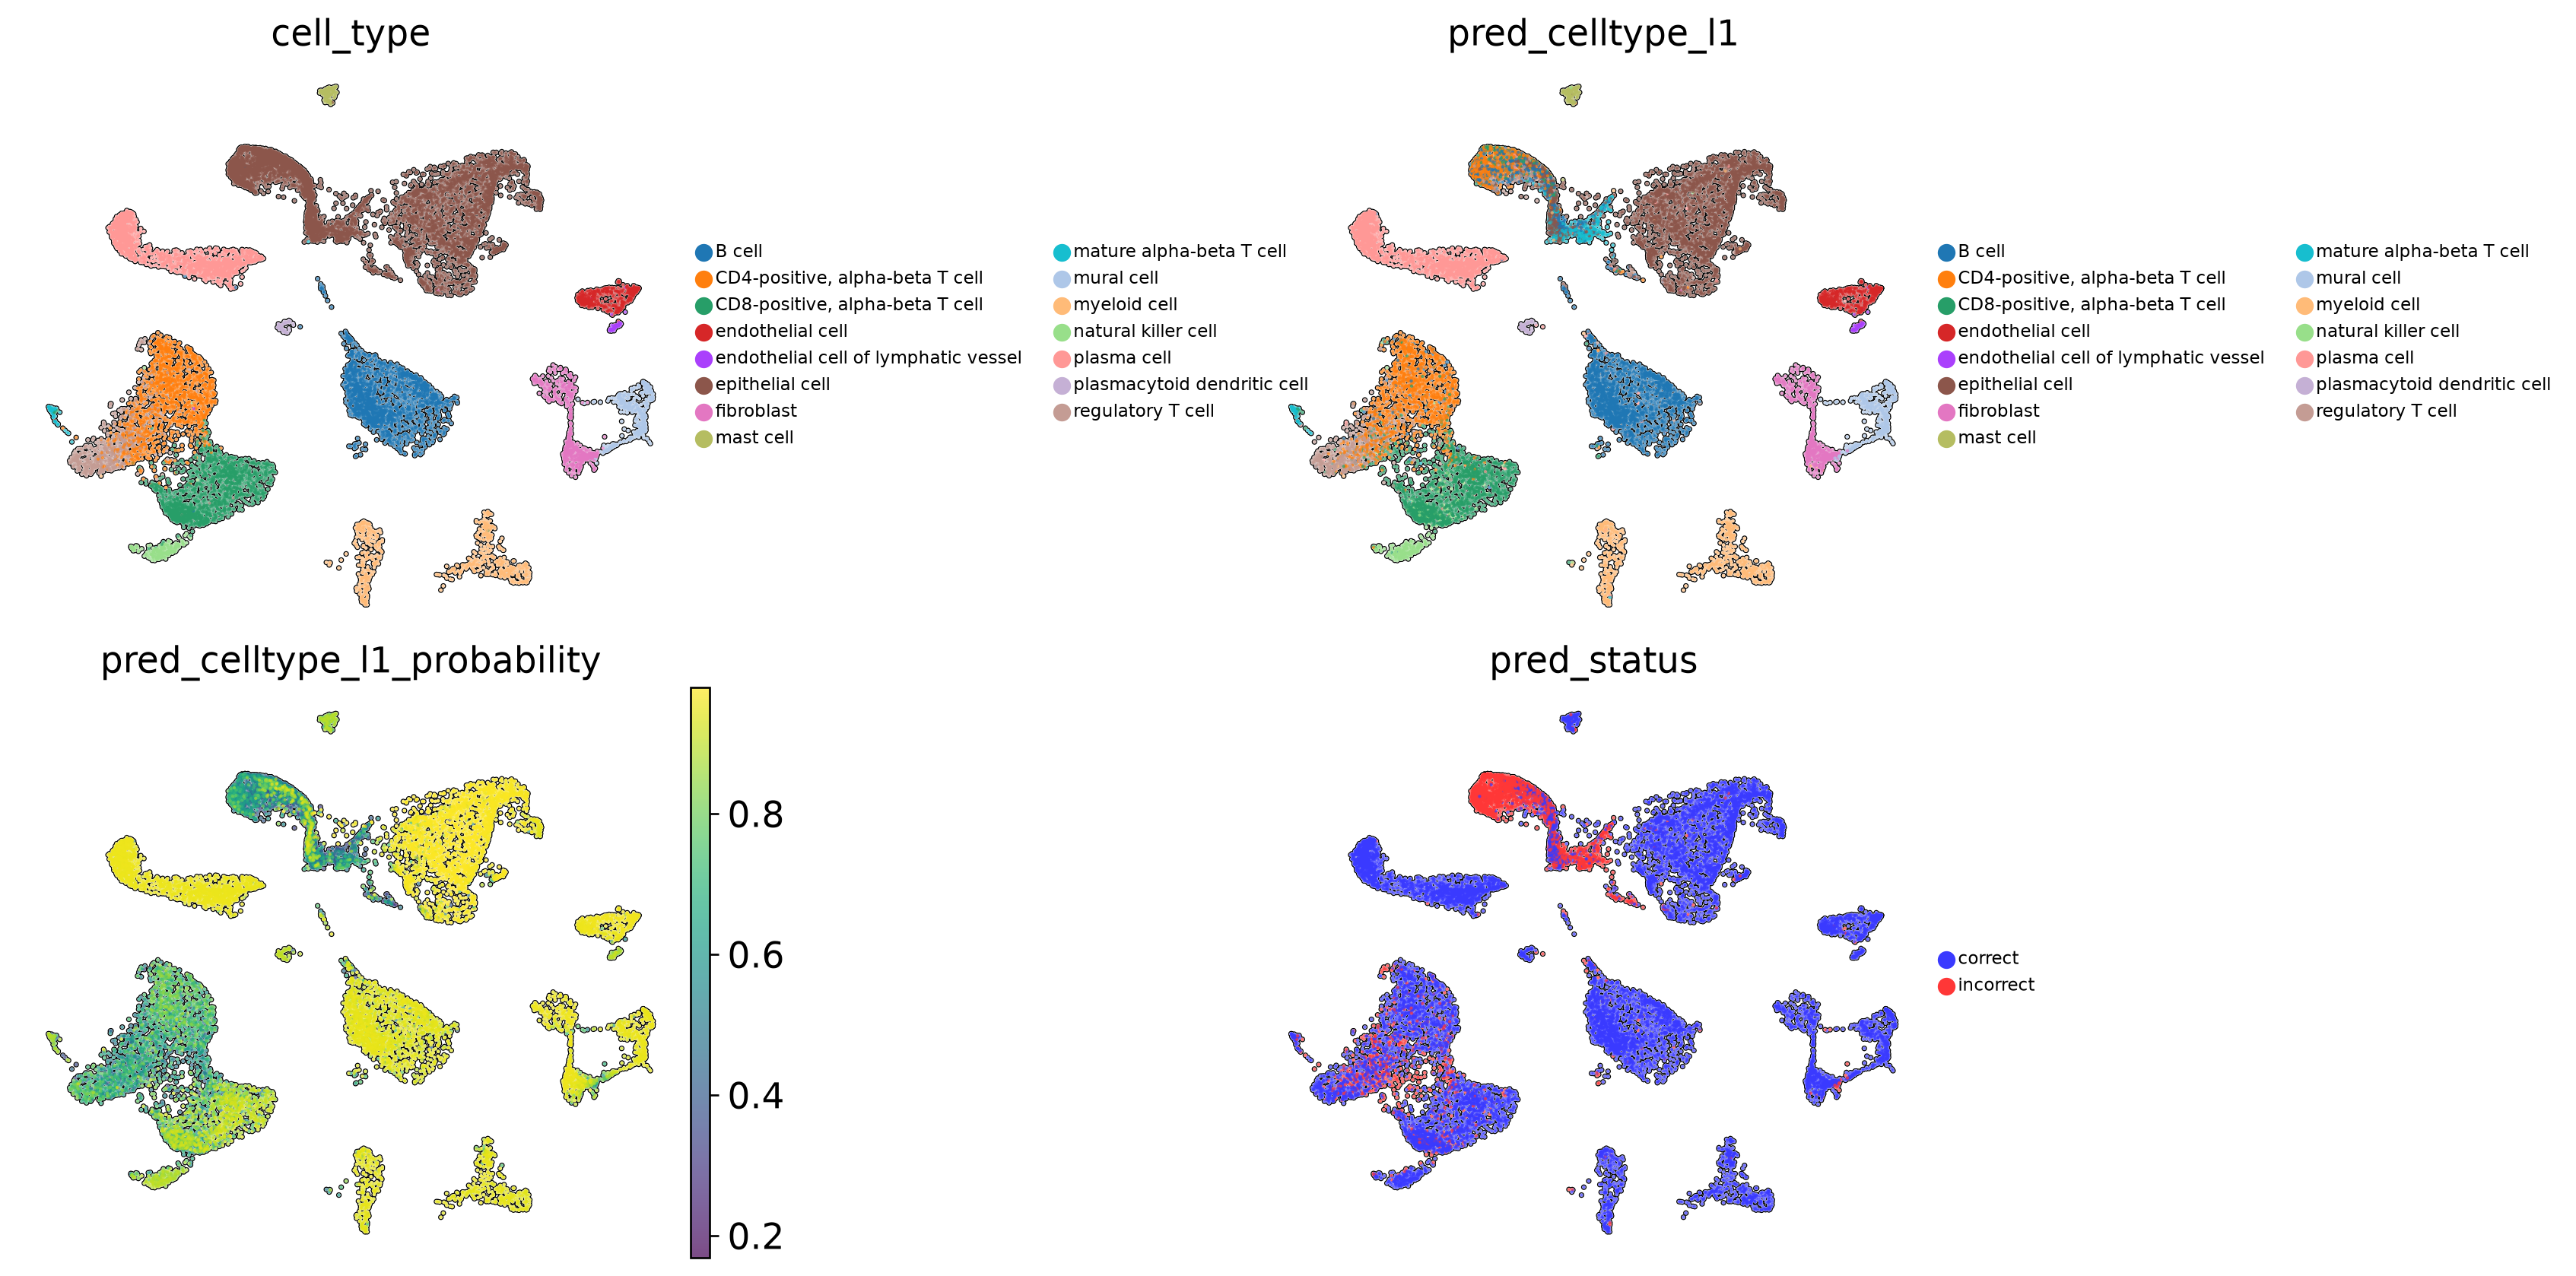

In [14]:
# Visualise predicted cell types levels, prediction probabilities and prediction status
sc.pl.umap(
    adata_test, 
    color=[
        'cell_type',
        'pred_celltype_l1',
        'pred_celltype_l1_probability',
        'pred_status'
    ],
    frameon = False,
    add_outline = True,
    legend_loc = 'right margin',
    legend_fontsize = 7,
    legend_fontoutline = 1,
    ncols=2,
    wspace = 0.7, 
    hspace = 0.1
)

## Warm start model training

<div class="alert alert-warning">
<b>Warning!</b>  <br> 
    For warm start scAdam model training, a dataset is required that contains all the same cell types that were present in the original training. <br>
    The cell types must be named exactly as they were during the initial training of the model. <br>

1) There should be no new additional cell types or levels of annotation.

2) Additionally, none of the cell types used for the initial training of the model should be missing.
</div>

In [15]:
# Warm start requires second training dataset and path to pretrained model 
scparadise.scadam.warm_start(
    adata_train_2,
    path='', # path to save model
    path_model='model_scadam', # folder name with pretrained model
    model_name='model_scadam_warm_start', # folder name with fine-tuned model
    celltype_keys=['cell_type'],
    eval_metric=['accuracy', 'balanced_accuracy']
)

scAdam model with unknown detector loaded from model_scadam
Device: cuda
Gene alignment:
 Number of features: 1200
 Matched features: 1200 (100.0%)
Label hierarchy: cell_type
Annotation levels weights using strategy 'linear_offset':
  cell_type: 15 cell types, 1.0 relative weight

Dataset split:
Train dataset contains: 25740 cells, it is 80.0 % of input dataset
Validation dataset contains: 6436 cells, it is 20.0 % of input dataset


Warm-start model fine-tuning:  21%|██▎        | 21/100 [01:48<06:49,  5.18s/it]

Early stopping triggered! Best score: 0.9513
Fitting unknown cells detector


UnknownCellDetector fitted successfully!
Model saved to model_scadam_warm_start


In [16]:
# Predict cell types using tuned model
adata_test = scparadise.scadam.predict(
    adata_test, 
    path_model = 'model_scadam_warm_start'
)

Cell type annotation using the 2nd version of the scAdam model
scAdam model with unknown detector loaded from model_scadam_warm_start
Gene alignment:
  Model features: 1200
  Matched features: 1200 (100.0%)


Predicting: 100%|█████████████████████████████| 72/72 [00:00<00:00, 178.42it/s]


Added cell type column: pred_celltype_l1
Added probabilities column: pred_celltype_l1_probability


### Evaluation of prediction results
Warm start leads to an increase in the model's accuracy (+17.1%), balanced accuracy (+4.3%), precision (+9.5%), f1-score (+10.2%), geometric mean (+3%), and index balanced accuracy (+5.5%). <br>

Below are examples of improved model performance for certain cell types. <br>

1) `mature alpha-beta T cell` (precision - 0.6837 vs 0.1199)

2) `regulatory T cell` (precision - 0.7475 vs 0.5116)

4) `epithelial cell` (sensitivity - 0.9800 vs 0.5229)

5) `CD4-positive, alpha-beta T cell` (precision - 0.8309 vs 0.4553)

6) `CD8-positive, alpha-beta T cell` (precision - 0.9252 vs 0.7178)

Full comparison is available below:

In [17]:
## Check model quality
df_warm_start = scparadise.scnoah.report_classif_full(
    adata_test,
    celltype='cell_type',
    pred_celltype='pred_celltype_l1'
)
df_warm_start

,precision,recall/sensitivity,specificity,f1-score,geometric mean,index balanced accuracy,number of cells
B cell,0.9906,0.9771,0.9988,0.9838,0.9879,0.9738,2050
"CD4-positive, alpha-beta T cell",0.8309,0.8571,0.9838,0.8438,0.9183,0.8326,1554
"CD8-positive, alpha-beta T cell",0.9252,0.9156,0.9922,0.9204,0.9531,0.9015,1742
endothelial cell,0.9956,0.9934,0.9999,0.9945,0.9967,0.9927,457
endothelial cell of lymphatic vessel,1.0000,1.0,1.0,1.0,1.0,1.0,52
epithelial cell,0.9930,0.98,0.9952,0.9865,0.9876,0.9738,7505
fibroblast,0.9938,0.9556,0.9998,0.9744,0.9774,0.9512,676
mast cell,0.9931,0.973,0.9999,0.9829,0.9864,0.9703,148
mature alpha-beta T cell,0.6837,0.8933,0.9983,0.7746,0.9444,0.8825,75
mural cell,0.9272,0.9908,0.9981,0.958,0.9945,0.9882,437


In [18]:
# Order cell type colors
celltype = np.unique(adata_test.obs['cell_type']).tolist()
adata_test.obs['cell_type'] = pd.Categorical(
    values=adata_test.obs['cell_type'], categories=celltype, ordered=True
)
adata_test.obs['pred_celltype_l1'] = pd.Categorical(
    values=adata_test.obs['pred_celltype_l1'], categories=celltype, ordered=True
)
# Add prediction status. Label cells as correct or incorrect based on the comparison between ground truth cell types and predictions.
scparadise.scnoah.pred_status(adata_test, celltype='cell_type', pred_celltype='pred_celltype_l1')

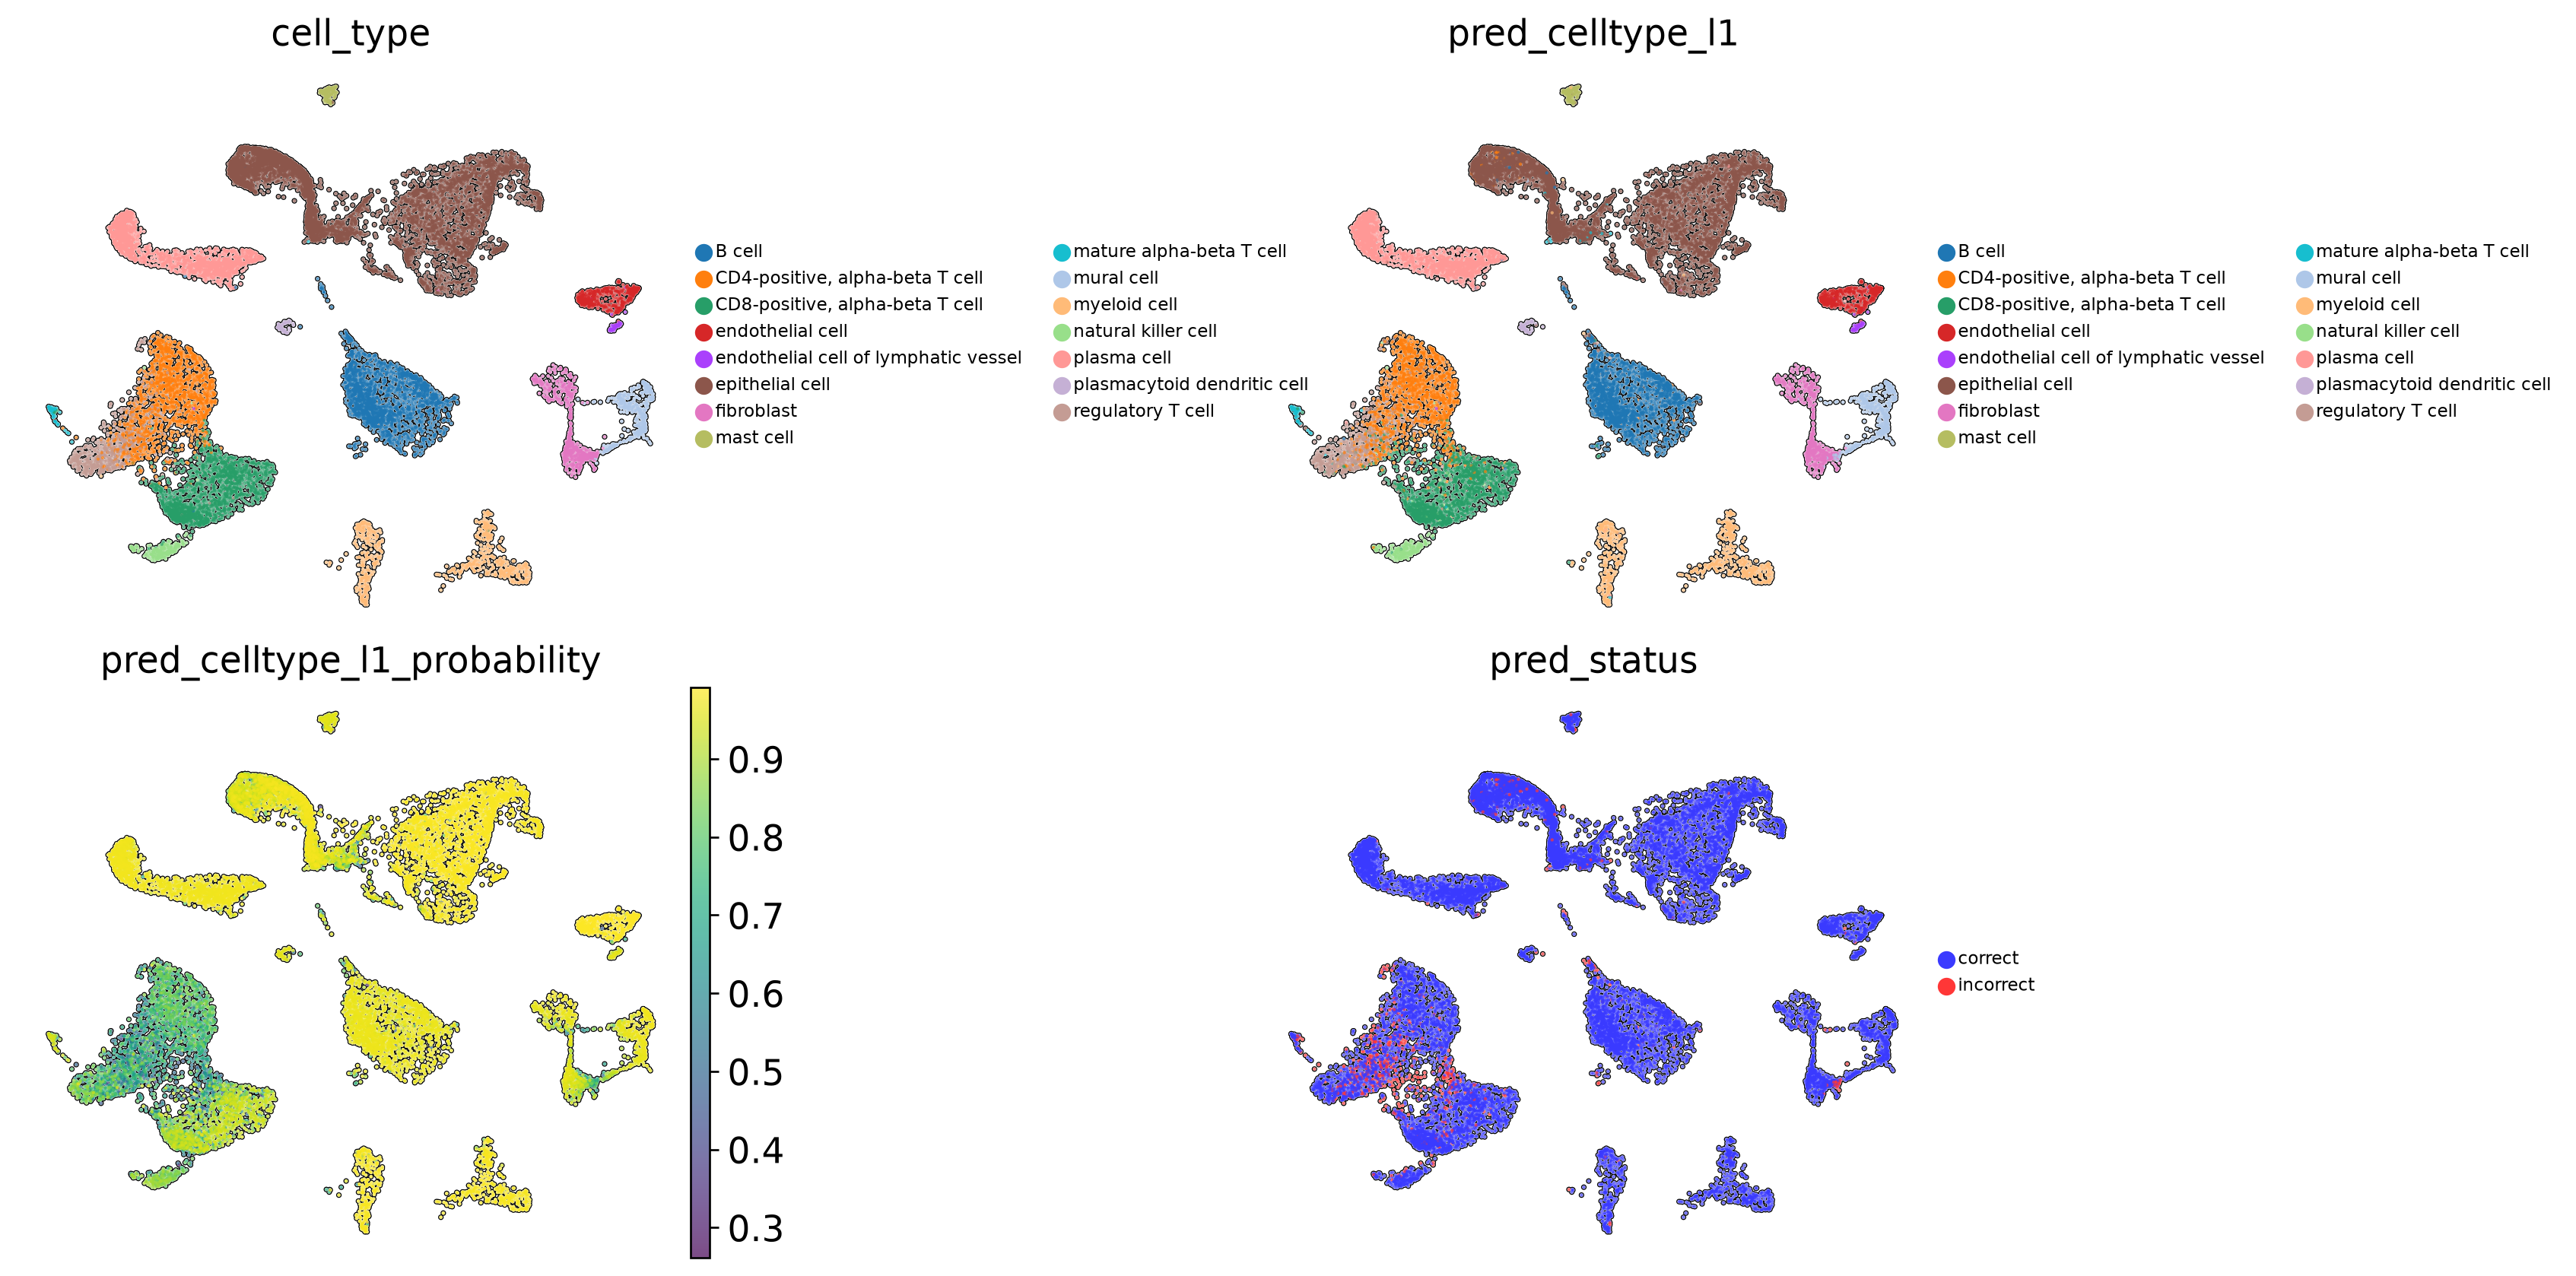

In [19]:
# Visualise predicted cell types levels, prediction probabilities and prediction status
sc.pl.umap(
    adata_test, 
    color=[
        'cell_type',
        'pred_celltype_l1',
        'pred_celltype_l1_probability',
        'pred_status'
    ],
    frameon = False,
    add_outline = True,
    legend_loc = 'right margin',
    legend_fontsize = 7,
    legend_fontoutline = 1,
    ncols=2,
    wspace = 0.7, 
    hspace = 0.1
)

In [20]:
# Compare prediction results
# 'untuned' row represents untuned model
# 'warm start' row represents warm start trained model
df.compare(df_warm_start, keep_equal=True, align_axis = 0, result_names=('untuned', 'warm start'))

precision recall/sensitivity  \
B cell                               untuned        0.6606              0.982   
                                     warm start     0.9906             0.9771   
CD4-positive, alpha-beta T cell      untuned        0.4553              0.816   
                                     warm start     0.8309             0.8571   
CD8-positive, alpha-beta T cell      untuned        0.7178              0.876   
                                     warm start     0.9252             0.9156   
endothelial cell                     untuned        1.0000             0.9912   
                                     warm start     0.9956             0.9934   
endothelial cell of lymphatic vessel untuned        1.0000             0.9615   
                                     warm start     1.0000                1.0   
epithelial cell                      untuned        0.9975             0.5229   
                                     warm start     0.9930               0.98   
fibroblast                           untuned        0.9864             0.9689   
                                     warm start     0.9938             0.9556   
mast cell                            untuned        0.9793             0.9595   
                                     warm start     0.9931              0.973   
mature alpha-beta T cell             untuned        0.1199             0.9067   
                                     warm start     0.6837             0.8933   
mural cell                           untuned        0.9554             0.9794   
                                     warm start     0.9272             0.9908   
myeloid cell                         untuned        0.9781             0.9862   
                                     warm start     0.9876             0.9848   
natural killer cell                  untuned        0.5815             0.9596   
                                     warm start     0.8220             0.9731   
plasma cell                          untuned        0.9647             0.9979   
                                     warm start     0.9912             0.9958   
plasmacytoid dendritic cell          untuned        0.9800               0.98   
                                     warm start     0.9608               0.98   
regulatory T cell                    untuned        0.5116             0.7055   
                                     warm start     0.7475             0.7726   
macro avg                            untuned        0.7926             0.9062   
                                     warm start     0.9228             0.9495   
weighted avg                         untuned        0.8545             0.7598   
                                     warm start     0.9580             0.9564   
Accuracy                             untuned        0.7598                      
                                     warm start     0.9564                      
Balanced accuracy                    untuned        0.9062                      
                                     warm start     0.9495                      

                                                specificity f1-score  \
B cell                               untuned         0.9364   0.7899   
                                     warm start      0.9988   0.9838   
CD4-positive, alpha-beta T cell      untuned         0.9094   0.5845   
                                     warm start      0.9838   0.8438   
CD8-positive, alpha-beta T cell      untuned         0.9638    0.789   
                                     warm start      0.9922   0.9204   
endothelial cell                     untuned            1.0   0.9956   
                                     warm start      0.9999   0.9945   
endothelial cell of lymphatic vessel untuned            1.0   0.9804   
                                     warm start         1.0      1.0   
epithelial cell                      untuned         0.9991   0.6861   
                         

## Hyperparameters tuning

<div class="alert alert-warning">
<b>Warning!</b>  <br> 
    Hyperparameter tuning is a very time-consuming process and may be interrupted for various reasons (such as system shutdowns or errors in CUDA). <br> 
    However, this is not a problem, as restarting the hyperparameter tuning will allow it to continue from the last unfinished trial. <br>
    An example of hyperparameter tuning represents such a case. <br>
    The fourth line states: "Using an existing study with name 'model_scadam_hp_tune' instead of creating a new one." <br>
    This indicates a restart of hyperparameter tuning (in this case, from the 8th trial).
</div>

In [21]:
scparadise.scadam.hyperparameter_tuning(
    adata_train_1,
    path='',
    model_name='model_scadam_hp_tune', # Folder to save hyperparameter tuning results
    celltype_keys=['cell_type'],
    num_trials=100, # The number of attempts to find the optimal hyperparameters for the model (recommended - minimum 100)
    eval_metric=['accuracy', 'balanced_accuracy']
)

Device: cuda
Number of features: 1200
Number of cells: 17173
Label hierarchy: cell_type
Annotation levels weights using strategy 'linear_offset':
  cell_type: 15 cell types, 1.0 relative weight
Start model optimization using optuna...


[I 2026-09-03 22:29:55,814] A new study created in RDB with name: study


Fold 1 finished with balanced_accuracy value = 0.950665
Fold 2 finished with balanced_accuracy value = 0.954470
Fold 3 finished with balanced_accuracy value = 0.958962
Fold 4 finished with balanced_accuracy value = 0.962636
Fold 5 finished with balanced_accuracy value = 0.962258


[I 2026-09-03 22:48:18,344] Trial 0 finished with value: 0.9577981523587649 and parameters: {'nc': 16, 'nb': 5, 'nh': 8, 'ed_nh_ratio': 32, 'ff_hd': 512, 'classifier_hd': 256, 'dropout': 0.3, 'lr': 0.0001, 'weight_decay': 0.0001, 'batch_size': 128, 'patience': 10, 'epochs': 200, 'use_augmentation': True, 'aug_probability': 0.5, 'prob': 0.15, 'noise_std': 0.1, 'dropout_aug': 0.1, 'alpha': 0.2, 'from_unsupervised': True, 'pretrain_epochs': 50}. Best is trial 0 with value: 0.9577981523587649.


Fold 1 finished with balanced_accuracy value = 0.559282
Fold 2 finished with balanced_accuracy value = 0.066667
Fold 3 finished with balanced_accuracy value = 0.778884
Fold 4 finished with balanced_accuracy value = 0.865783
Fold 5 finished with balanced_accuracy value = 0.737923


...

[I 2026-09-04 03:49:40,621] Trial 98 pruned. 


Fold 1 finished with balanced_accuracy value = 0.950296


[I 2026-09-04 03:50:45,741] Trial 99 pruned. 


Best value (balanced_accuracy) = 0.9615867721230634
Best hyperparameters saved to: model_scadam_hp_tune/best_params.txt


{'nc': 4,
 'nb': 5,
 'nh': 16,
 'ed_nh_ratio': 28,
 'ff_hd': 768,
 'classifier_hd': 896,
 'dropout': 0.23698142213184742,
 'lr': 6.963690736722135e-05,
 'weight_decay': 0.0034732362400466494,
 'batch_size': 1408,
 'patience': 30,
 'epochs': 195,
 'use_augmentation': True,
 'aug_probability': 0.7677578787467152,
 'prob': 0.20685827234760135,
 'noise_std': 0.10838449541841462,
 'dropout_aug': 0.00177856974742846,
 'alpha': 0.04645915647446934,
 'from_unsupervised': False,
 'pretrain_epochs': 25}

In [22]:
# Train model using optimal parameters from model_scadam_hp_tune folder
scparadise.scadam.train_tuned(
    adata_train_1,
    path='', # path to save model
    path_tuned='model_scadam_hp_tune', # path to a folder with tuned hyperparameters
    model_name='model_scadam_tuned', # folder name with model
    celltype_keys=['cell_type'],
    eval_metric=['accuracy', 'balanced_accuracy']
)

Successfully loaded tuned hyperparameters!
Device: cuda
Number of features: 1200
Label hierarchy: cell_type
Annotation levels weights using strategy 'linear_offset':
  cell_type: 15 cell types, 1.0 relative weight

Dataset split:
Train dataset contains: 13738 cells, it is 80.0 % of input dataset
Validation dataset contains: 3435 cells, it is 20.0 % of input dataset


Training scAdam model:  37%|██████▋           | 73/195 [00:41<01:09,  1.75it/s]

Early stopping triggered! Best score: 0.9635
Training completed!
Fitting unknown cells detector


UnknownCellDetector fitted successfully!
Model saved to model_scadam_tuned


In [23]:
# Predict cell types using trained model
adata_test = scparadise.scadam.predict(
    adata_test, 
    path_model = 'model_scadam_tuned'
)

Cell type annotation using the 2nd version of the scAdam model
scAdam model with unknown detector loaded from model_scadam_tuned
Gene alignment:
  Model features: 1200
  Matched features: 1200 (100.0%)


Predicting: 100%|█████████████████████████████| 72/72 [00:00<00:00, 161.81it/s]


Added cell type column: pred_celltype_l1
Added probabilities column: pred_celltype_l1_probability


### Evaluation of prediction results
Hyperparameters tuning leads to an increase in the model's overall accuracy (+4.37%) and balanced accuracy (+1.33%). <br>

Below are examples of improved model performance for certain cell types. <br>

1) `CD8-positive, alpha-beta T cell` (precision - 0.8742 vs 0.7178)

2) `B cell` (precision - 0.9258 vs 0.6606)

3) `epithelial cell` (sensitivity - 0.6108 vs 0.5229)

4) `natural killer cell` (precision - 0.6977 vs 0.5815)

5) `regulatory T cell` (precision - 0.7010 vs 0.5116)

However, a decrease in prediction accuracy may be observed for some cell types. <br>

1) `CD4-positive, alpha-beta T cell` (sensitivity - 0.3840 vs 0.4553)

In [24]:
## Check model quality
df_hp_tuned = scparadise.scnoah.report_classif_full(
    adata_test,
    celltype='cell_type',
    pred_celltype='pred_celltype_l1'
)
df_hp_tuned

,precision,recall/sensitivity,specificity,f1-score,geometric mean,index balanced accuracy,number of cells
B cell,0.9258,0.98,0.9901,0.9521,0.985,0.9693,2050
"CD4-positive, alpha-beta T cell",0.3840,0.8578,0.8723,0.5305,0.865,0.7472,1554
"CD8-positive, alpha-beta T cell",0.8742,0.9133,0.9862,0.8933,0.949,0.8941,1742
endothelial cell,0.9934,0.9869,0.9998,0.9901,0.9933,0.9854,457
endothelial cell of lymphatic vessel,1.0000,0.9808,1.0,0.9903,0.9903,0.9789,52
epithelial cell,0.9957,0.6108,0.9981,0.7571,0.7808,0.586,7505
fibroblast,0.9820,0.966,0.9993,0.9739,0.9825,0.9621,676
mast cell,0.9726,0.9595,0.9998,0.966,0.9794,0.9554,148
mature alpha-beta T cell,0.0941,0.8933,0.9646,0.1703,0.9283,0.8556,75
mural cell,0.9449,0.9817,0.9986,0.963,0.9901,0.9787,437


In [25]:
# Order cell type colors
celltype = np.unique(adata_test.obs['cell_type']).tolist()
adata_test.obs['cell_type'] = pd.Categorical(
    values=adata_test.obs['cell_type'], categories=celltype, ordered=True
)
adata_test.obs['pred_celltype_l1'] = pd.Categorical(
    values=adata_test.obs['pred_celltype_l1'], categories=celltype, ordered=True
)
# Add prediction status. Label cells as correct or incorrect based on the comparison between ground truth cell types and predictions.
scparadise.scnoah.pred_status(adata_test, celltype='cell_type', pred_celltype='pred_celltype_l1')

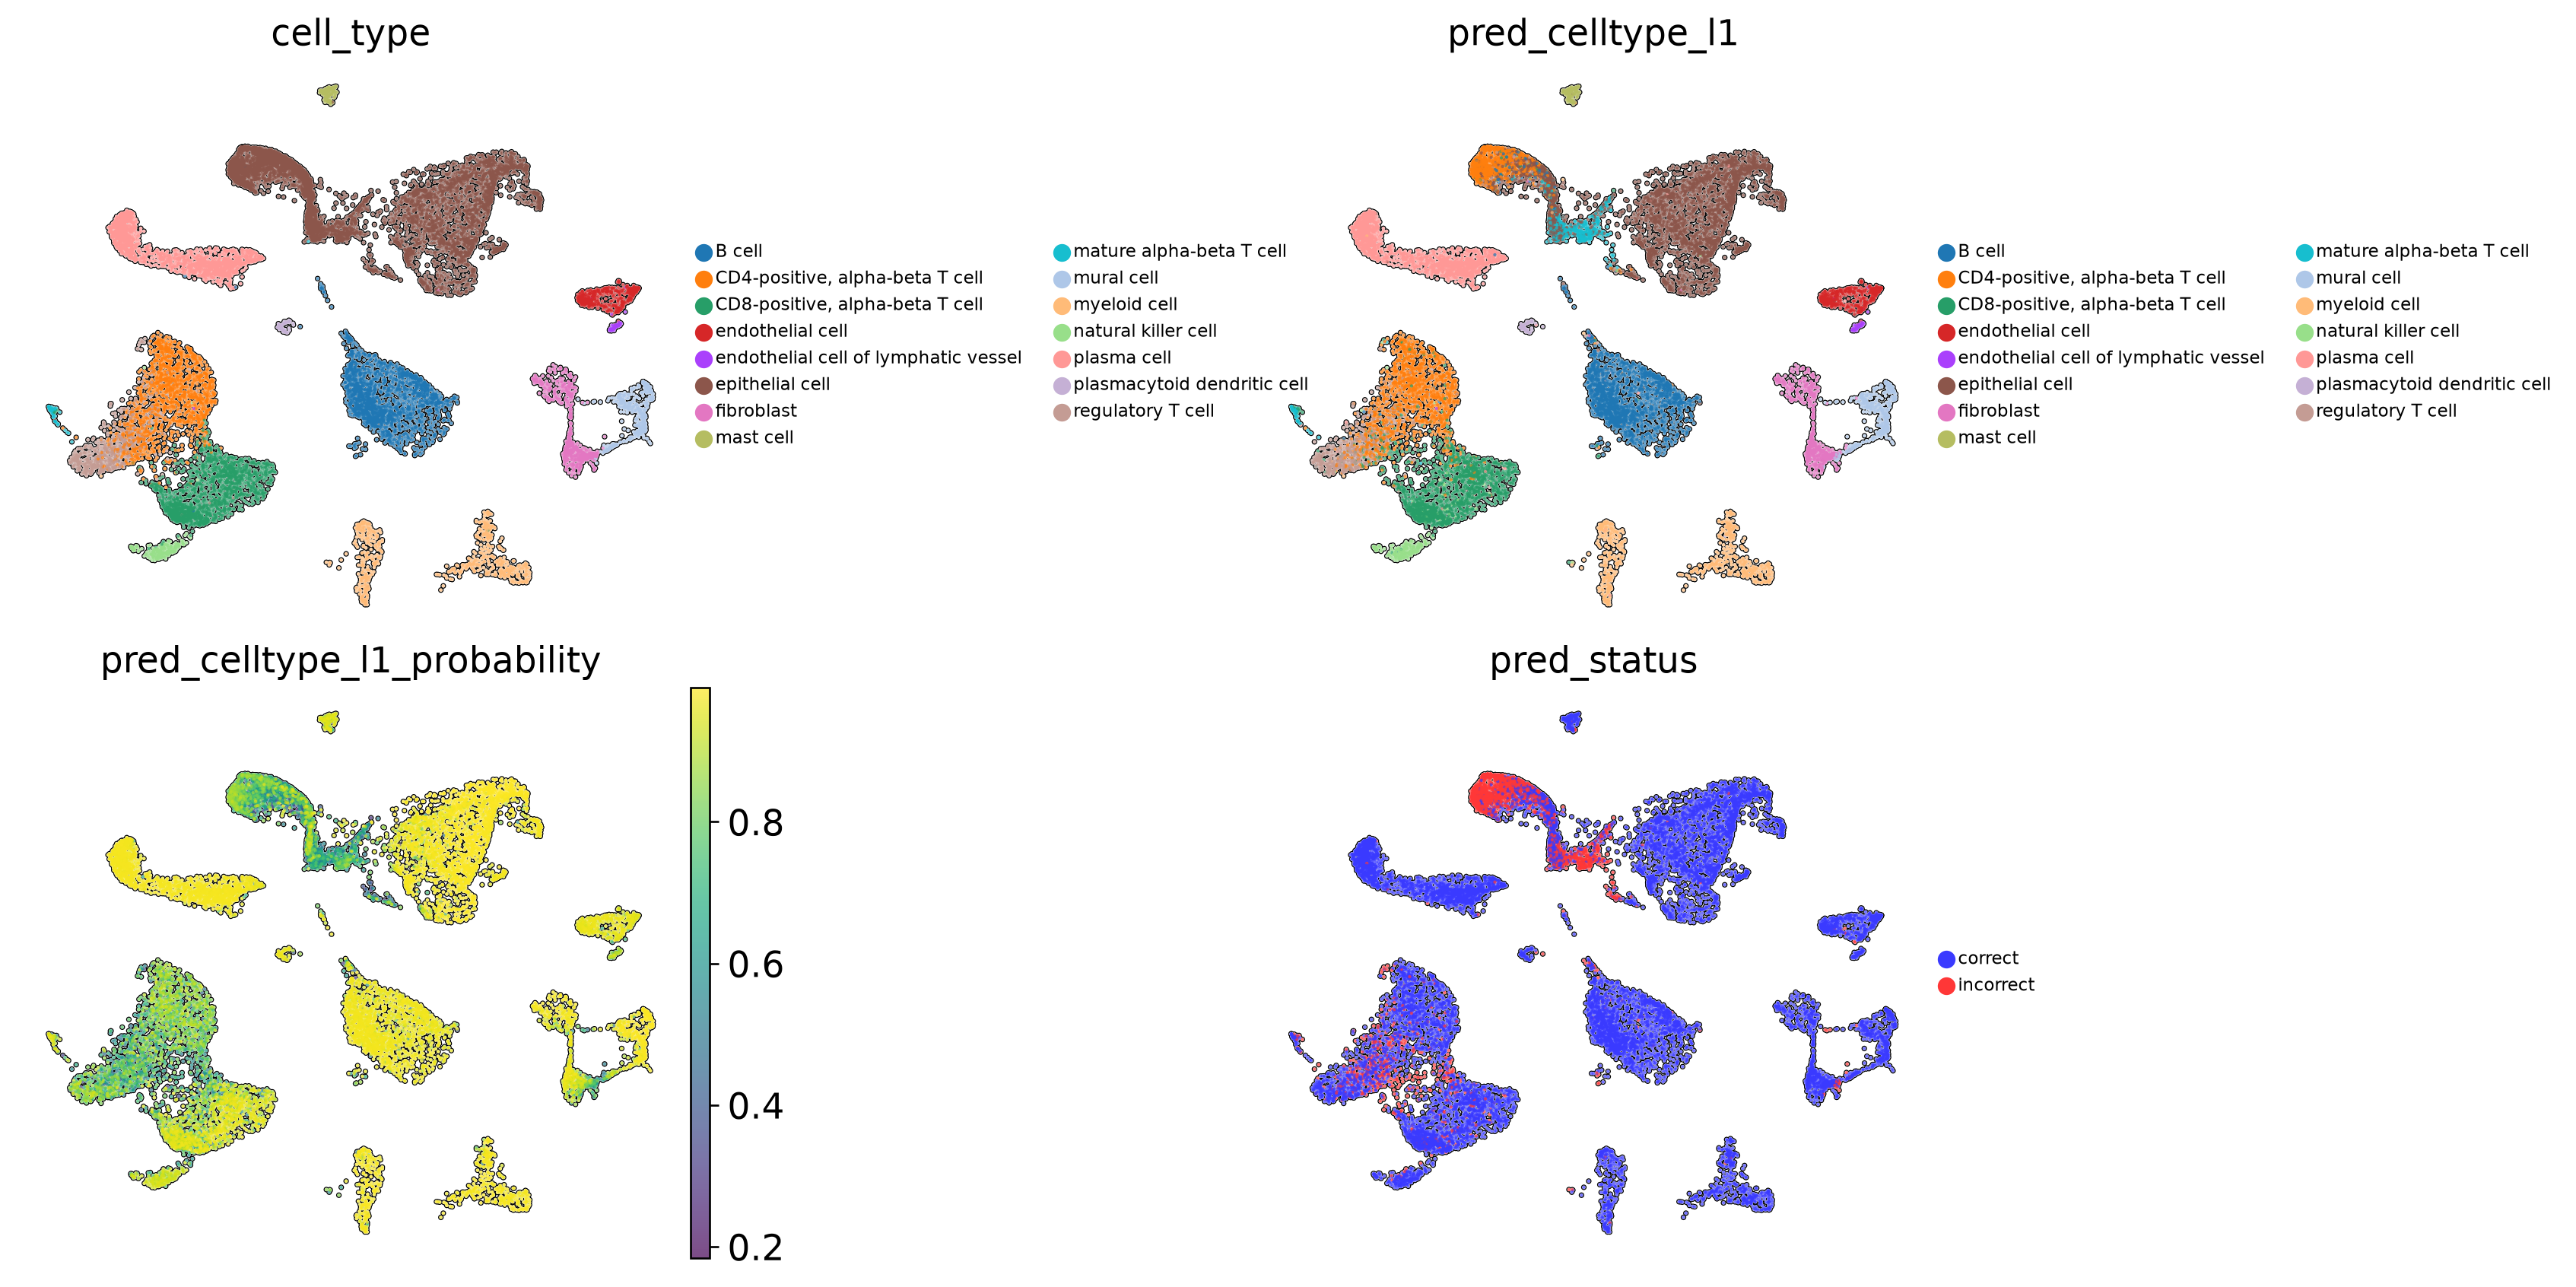

In [26]:
# Visualise predicted cell types levels, prediction probabilities and prediction status
sc.pl.umap(
    adata_test, 
    color=[
        'cell_type',
        'pred_celltype_l1',
        'pred_celltype_l1_probability',
        'pred_status'
    ],
    frameon = False,
    add_outline = True,
    legend_loc = 'right margin',
    legend_fontsize = 7,
    legend_fontoutline = 1,
    ncols=2,
    wspace = 0.7, 
    hspace = 0.1
)

In [27]:
# Compare prediction results
# 'untuned' row represents untuned model
# 'hp tuned' row represents tuned model
df.compare(df_hp_tuned, keep_equal=True, align_axis = 0, result_names=('untuned', 'hp tuned'))

precision recall/sensitivity  \
B cell                               untuned      0.6606              0.982   
                                     hp tuned     0.9258               0.98   
CD4-positive, alpha-beta T cell      untuned      0.4553              0.816   
                                     hp tuned     0.3840             0.8578   
CD8-positive, alpha-beta T cell      untuned      0.7178              0.876   
                                     hp tuned     0.8742             0.9133   
endothelial cell                     untuned      1.0000             0.9912   
                                     hp tuned     0.9934             0.9869   
endothelial cell of lymphatic vessel untuned      1.0000             0.9615   
                                     hp tuned     1.0000             0.9808   
epithelial cell                      untuned      0.9975             0.5229   
                                     hp tuned     0.9957             0.6108   
fibroblast                           untuned      0.9864             0.9689   
                                     hp tuned     0.9820              0.966   
mast cell                            untuned      0.9793             0.9595   
                                     hp tuned     0.9726             0.9595   
mature alpha-beta T cell             untuned      0.1199             0.9067   
                                     hp tuned     0.0941             0.8933   
mural cell                           untuned      0.9554             0.9794   
                                     hp tuned     0.9449             0.9817   
myeloid cell                         untuned      0.9781             0.9862   
                                     hp tuned     0.9782             0.9876   
natural killer cell                  untuned      0.5815             0.9596   
                                     hp tuned     0.6977             0.9731   
plasma cell                          untuned      0.9647             0.9979   
                                     hp tuned     0.9825             0.9974   
plasmacytoid dendritic cell          untuned      0.9800               0.98   
                                     hp tuned     0.9423               0.98   
regulatory T cell                    untuned      0.5116             0.7055   
                                     hp tuned     0.7010             0.7245   
macro avg                            untuned      0.7926             0.9062   
                                     hp tuned     0.8312             0.9195   
weighted avg                         untuned      0.8545             0.7598   
                                     hp tuned     0.9018             0.8035   
Accuracy                             untuned      0.7598                      
                                     hp tuned     0.8035                      
Balanced accuracy                    untuned      0.9062                      
                                     hp tuned     0.9195                      

                                              specificity f1-score  \
B cell                               untuned       0.9364   0.7899   
                                     hp tuned      0.9901   0.9521   
CD4-positive, alpha-beta T cell      untuned       0.9094   0.5845   
                                     hp tuned      0.8723   0.5305   
CD8-positive, alpha-beta T cell      untuned       0.9638    0.789   
                                     hp tuned      0.9862   0.8933   
endothelial cell                     untuned          1.0   0.9956   
                                     hp tuned      0.9998   0.9901   
endothelial cell of lymphatic vessel untuned          1.0   0.9804   
                                     hp tuned         1.0   0.9903   
epithelial cell                      untuned       0.9991   0.6861   
                                     hp tuned      0.9981   0.7571   
fibroblast                           untuned       0.99

In [28]:
# Compare prediction results
# 'warm start' row represents warm start trained model
# 'hp tuned' row represents tuned model
df_warm_start.compare(df_hp_tuned, keep_equal=True, align_axis = 0, result_names=('warm start', 'hp tuned'))

precision recall/sensitivity  \
B cell                               warm start     0.9906             0.9771   
                                     hp tuned       0.9258               0.98   
CD4-positive, alpha-beta T cell      warm start     0.8309             0.8571   
                                     hp tuned       0.3840             0.8578   
CD8-positive, alpha-beta T cell      warm start     0.9252             0.9156   
                                     hp tuned       0.8742             0.9133   
endothelial cell                     warm start     0.9956             0.9934   
                                     hp tuned       0.9934             0.9869   
endothelial cell of lymphatic vessel warm start     1.0000                1.0   
                                     hp tuned       1.0000             0.9808   
epithelial cell                      warm start     0.9930               0.98   
                                     hp tuned       0.9957             0.6108   
fibroblast                           warm start     0.9938             0.9556   
                                     hp tuned       0.9820              0.966   
mast cell                            warm start     0.9931              0.973   
                                     hp tuned       0.9726             0.9595   
mature alpha-beta T cell             warm start     0.6837             0.8933   
                                     hp tuned       0.0941             0.8933   
mural cell                           warm start     0.9272             0.9908   
                                     hp tuned       0.9449             0.9817   
myeloid cell                         warm start     0.9876             0.9848   
                                     hp tuned       0.9782             0.9876   
natural killer cell                  warm start     0.8220             0.9731   
                                     hp tuned       0.6977             0.9731   
plasma cell                          warm start     0.9912             0.9958   
                                     hp tuned       0.9825             0.9974   
plasmacytoid dendritic cell          warm start     0.9608               0.98   
                                     hp tuned       0.9423               0.98   
regulatory T cell                    warm start     0.7475             0.7726   
                                     hp tuned       0.7010             0.7245   
macro avg                            warm start     0.9228             0.9495   
                                     hp tuned       0.8312             0.9195   
weighted avg                         warm start     0.9580             0.9564   
                                     hp tuned       0.9018             0.8035   
Accuracy                             warm start     0.9564                      
                                     hp tuned       0.8035                      
Balanced accuracy                    warm start     0.9495                      
                                     hp tuned       0.9195                      

                                                specificity f1-score  \
B cell                               warm start      0.9988   0.9838   
                                     hp tuned        0.9901   0.9521   
CD4-positive, alpha-beta T cell      warm start      0.9838   0.8438   
                                     hp tuned        0.8723   0.5305   
CD8-positive, alpha-beta T cell      warm start      0.9922   0.9204   
                                     hp tuned        0.9862   0.8933   
endothelial cell                     warm start      0.9999   0.9945   
                                     hp tuned        0.9998   0.9901   
endothelial cell of lymphatic vessel warm start         1.0      1.0   
                                     hp tuned           1.0   0.9903   
epithelial cell                      warm start      0.9952   0.9865   
                         

## Recommendation

When possible, we recommend <strong>warm-start</strong> training rather than <strong>hyperparameter tuning</strong>. If an additional training dataset is unavailable, hyperparameter tuning can be used to optimize model performance.

<strong>Warm-start</strong> approaches can reuse information from prior training or tuning runs, potentially reducing the number of new experiments needed; however, their benefit depends on how similar the new training data are to the original data.

In [29]:
import session_info2
session_info2.session_info()

Package,Version
pandas,2.3.3
scanpy,1.11.5
scparadise,1.2.0
matplotlib,3.11.0
numpy,2.4.6
anndata,0.12.16
Component,Info
Python,"3.11.15 (main, Jun 11 2026, 15:20:16) [GCC 14.3.0]"
OS,Linux-6.8.0-138-generic-x86_64-with-glibc2.39
Updated,2026-09-04 03:51
